In [16]:
pip install mysql-connector-python

   ---------------------------------------- 0.0/17.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.0 MB ? eta -:--:--
   -- ------------------------------------- 1.0/17.0 MB 9.3 MB/s eta 0:00:02
   ------------ --------------------------- 5.5/17.0 MB 16.3 MB/s eta 0:00:01
   ------------------------- -------------- 10.7/17.0 MB 20.3 MB/s eta 0:00:01
   --------------------------------- ------ 14.4/17.0 MB 19.4 MB/s eta 0:00:01
   ------------------------------------ --- 15.5/17.0 MB 17.2 MB/s eta 0:00:01
   -------------------------------------- - 16.3/17.0 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------  16.8/17.0 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 17.0/17.0 MB 11.2 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="1234567890",
    database="sample",
    port=3306

)
df = pd.read_sql("select * from sales",conn)
print(df.head())

   sale_id   sale_date  customer_name    product_name       category  \
0        1  2024-01-15     John Smith          Laptop    Electronics   
1        2  2024-01-16   Emma Johnson    Office Chair      Furniture   
2        3  2024-01-17  Michael Brown      Smartphone    Electronics   
3        4  2024-01-18    Sarah Davis       Desk Lamp  Home & Office   
4        5  2024-01-19   James Wilson  Wireless Mouse    Electronics   

   quantity  unit_price  total_amount region payment_method  
0         1      899.99        899.99  North    Credit Card  
1         2      149.50        299.00  South     Debit Card  
2         1      699.99        699.99   East    Credit Card  
3         3       29.99         89.97   West           Cash  
4         5       24.99        124.95  North    Credit Card  


C:\Users\DELL\AppData\Local\Temp\ipykernel_23904\1557823247.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("select * from sales",conn)


In [21]:
df.shape

(30, 10)

In [22]:
print(df.describe())

         sale_id   quantity  unit_price  total_amount
count  30.000000  30.000000   30.000000     30.000000
mean   15.500000   2.833333  155.857333    213.209000
std     8.803408   2.320573  208.721145    196.679673
min     1.000000   1.000000    9.990000     39.980000
25%     8.250000   1.000000   24.990000     91.477500
50%    15.500000   2.000000   84.990000    149.970000
75%    22.750000   4.000000  179.990000    222.490000
max    30.000000  10.000000  899.990000    899.990000


In [23]:
print(df['category'].unique())
print(df['region'].value_counts())

['Electronics' 'Furniture' 'Home & Office' 'Stationery' 'Accessories']
region
North    8
South    8
East     7
West     7
Name: count, dtype: int64


Top 5 selling products by quantity

In [25]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending= False)
top_products

product_name
Notebook Set           10
Pen Set                 8
Stapler Set             6
USB Hub                 6
Power Bank              5
Wireless Mouse          5
Ergonomic Mouse Pad     4
Desk Organizer          4
Surge Protector         4
Desk Lamp               3
Keyboard                3
Laptop Bag              3
Monitor                 2
External Hard Drive     2
Webcam                  2
Desk Mat                2
Office Chair            2
Smart Speaker           2
Coffee Maker            1
Headphones              1
Filing Cabinet          1
Bookshelf               1
Laptop                  1
Scanner                 1
Router                  1
Printer                 1
Smartphone              1
Standing Desk           1
Tablet                  1
Whiteboard              1
Name: quantity, dtype: int64

payment method analyasis

payment_method
Cash            566.75
Credit Card    4504.70
Debit Card     1324.82
Name: total_amount, dtype: float64

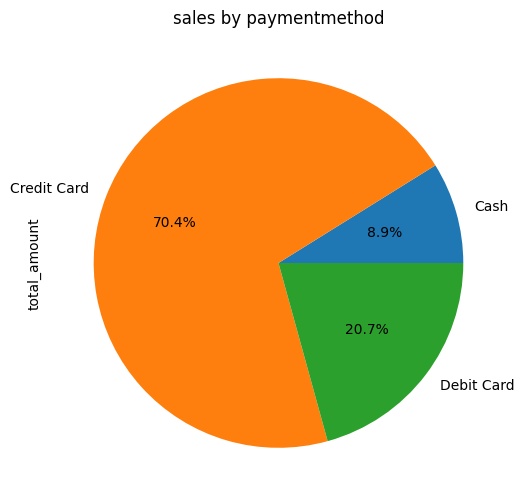

In [26]:
payment_analyasis = df.groupby('payment_method')['total_amount'].sum()
payment_analyasis.plot(kind='pie',autopct='%1.1f%%',figsize=(6,6),title="sales by paymentmethod")
payment_analyasis

C:\Users\DELL\AppData\Local\Temp\ipykernel_23904\900217632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='region', y='total_amount', palette='coolwarm')


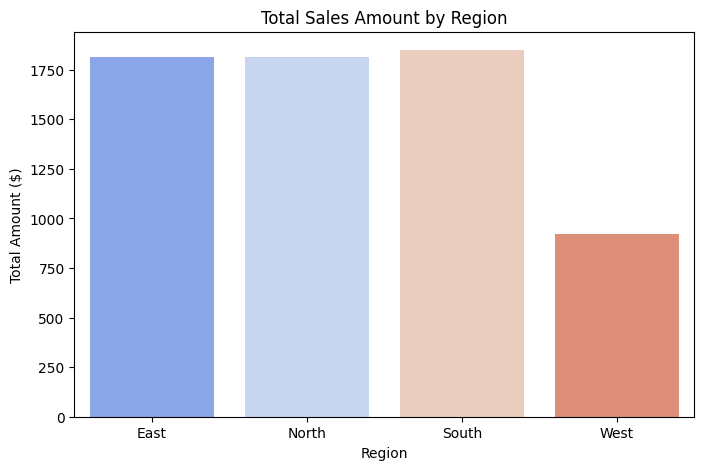

In [27]:
region_sales = df.groupby('region')['total_amount'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='region', y='total_amount', palette='coolwarm')
plt.title("Total Sales Amount by Region")
plt.ylabel("Total Amount ($)")
plt.xlabel("Region")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_23904\2934499192.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['category'].value_counts().index,


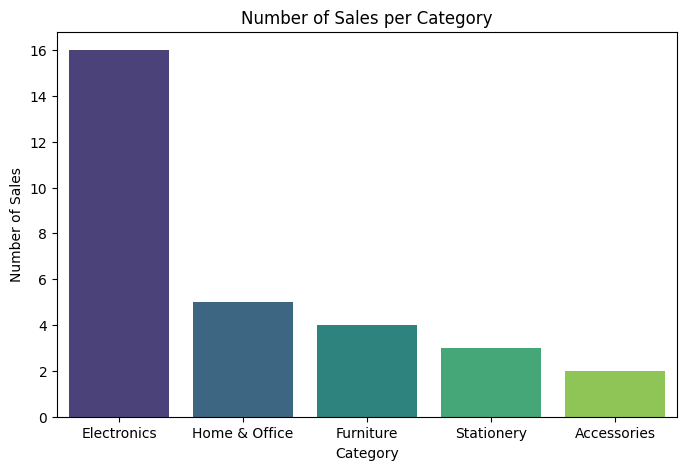

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=df['category'].value_counts().index, 
            y=df['category'].value_counts().values, palette='viridis')
plt.title("Number of Sales per Category")
plt.ylabel("Number of Sales")
plt.xlabel("Category")
plt.show()

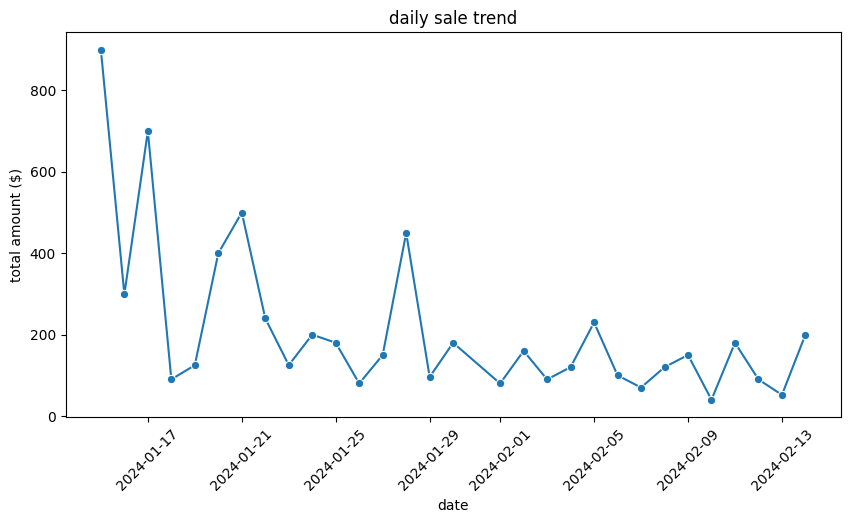

In [29]:
df['sale_date']= pd.to_datetime(df['sale_date'])
daily_sales = df.groupby('sale_date')['total_amount'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_sales, x='sale_date',y='total_amount',marker='o')
plt.title("daily sale trend")
plt.ylabel("total amount ($)")
plt.xlabel('date')
plt.xticks(rotation=45)
plt.show()